# PharmaStock Optimizer — EDA & Demand Forecasting Evaluation

This notebook explores the historical pharmacy sales dataset and evaluates the
per-medicine XGBoost stockout-forecasting pipeline used in production
(`ml/forecasting.py`). It reuses the actual production feature-engineering and
training code — the results here are the same ones the running app produces,
not a separate throwaway analysis.

**Walkthrough:**
1. Exploratory analysis of ~33K sales records across 33 medicines
2. The feature engineering used by the production pipeline
3. A time-based train/test evaluation (chronological, not randomly shuffled —
   shuffling time-ordered data would leak the future into training)
4. A naive baseline comparison, so the model's value is quantified, not assumed
5. Honest results, including a real overfitting finding caught by proper
   validation, and what it implies about the data

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # repo root, to reuse the app's own ML/data code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 20)

ACCENT = "#0F766E"

## 1. Load the data

In [2]:
df = pd.read_csv("../expanded_sales_data.csv")
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
print(f"{len(df):,} rows | {df['Medicine_Name'].nunique()} medicines | "
      f"{df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

33,264 rows | 33 medicines | 2022-01-01 to 2024-12-28


,Date,Month,Year,Medicine_Name,ATC_Code,Stock_Available,Stock_Sold,Stockout_Flag,External_Factor,Price_per_Unit,Supplier_ID,Reorder_Level,Days_to_Stockout
0,2022-01-01,January,2022,Diclofenac,M01AB,100,28,0,Low,13.89,SUP002,33,2
1,2022-01-01,January,2022,Ketoprofen,M01AB,315,45,0,Low,6.38,SUP005,81,6
2,2022-01-01,January,2022,Naproxen,M01AB,179,42,0,High,9.60,SUP004,100,3
3,2022-01-01,January,2022,Ibuprofen,M01AE,305,13,0,High,5.87,SUP002,63,22
4,2022-01-01,January,2022,Dexibuprofen,M01AE,361,10,0,Low,14.64,SUP008,25,35


## 2. Data quality check

In [3]:
df.isna().sum().to_frame("missing_values").T

,Date,Month,Year,Medicine_Name,ATC_Code,Stock_Available,Stock_Sold,Stockout_Flag,External_Factor,Price_per_Unit,Supplier_ID,Reorder_Level,Days_to_Stockout
missing_values,0,0,0,0,0,0,0,0,0,0,0,0,0


## 3. Overall sales trend

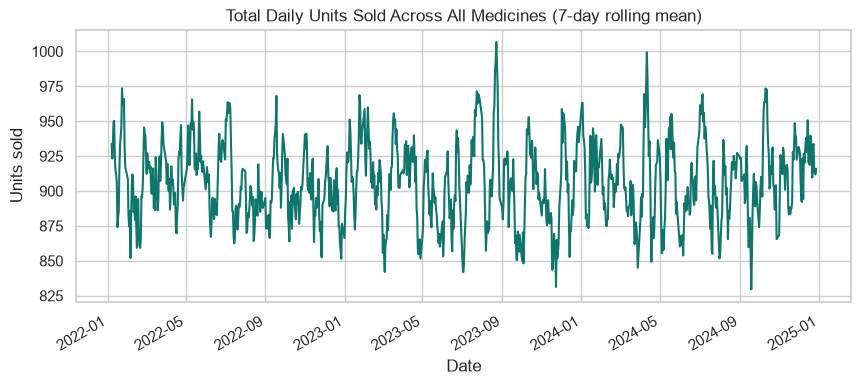

In [4]:
daily_total = df.groupby("Date")["Stock_Sold"].sum()

fig, ax = plt.subplots()
daily_total.rolling(7).mean().plot(ax=ax, color=ACCENT)
ax.set_title("Total Daily Units Sold Across All Medicines (7-day rolling mean)")
ax.set_ylabel("Units sold")
plt.show()

## 4. Top medicines by volume

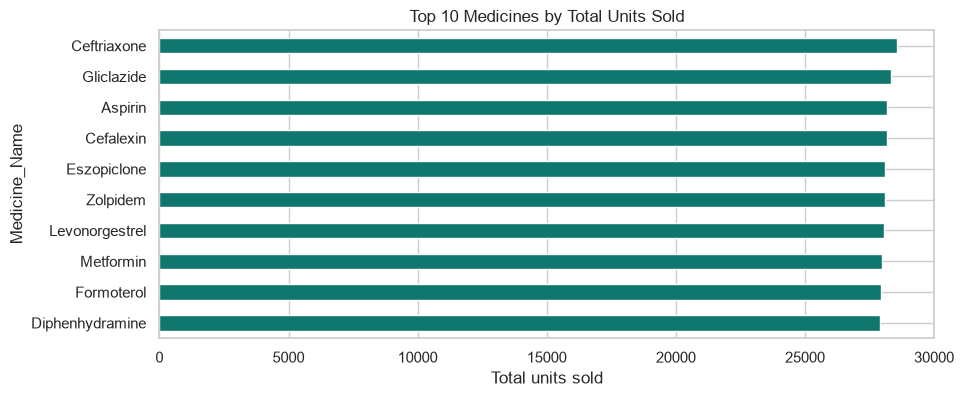

In [5]:
top_medicines = df.groupby("Medicine_Name")["Stock_Sold"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_medicines.plot(kind="barh", ax=ax, color=ACCENT)
ax.invert_yaxis()
ax.set_title("Top 10 Medicines by Total Units Sold")
ax.set_xlabel("Total units sold")
plt.show()

## 5. Seasonality — day of week & month

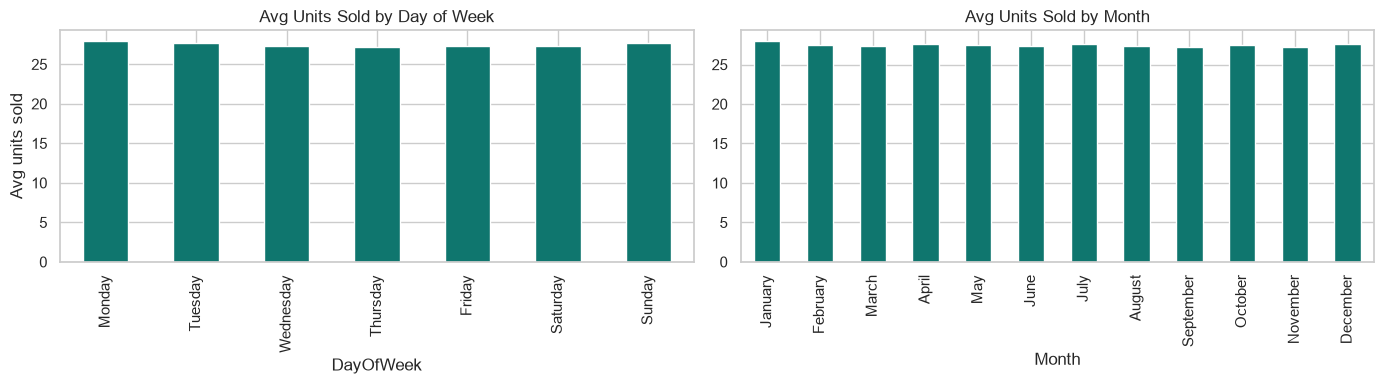

In [6]:
df["DayOfWeek"] = df["Date"].dt.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby("DayOfWeek")["Stock_Sold"].mean().reindex(dow_order).plot(kind="bar", ax=axes[0], color=ACCENT)
axes[0].set_title("Avg Units Sold by Day of Week")
axes[0].set_ylabel("Avg units sold")

df.groupby("Month")["Stock_Sold"].mean().reindex(month_order).plot(kind="bar", ax=axes[1], color=ACCENT)
axes[1].set_title("Avg Units Sold by Month")
plt.tight_layout()
plt.show()

## 6. Does `External_Factor` carry signal?

The dataset includes an `External_Factor` column (High/Medium/Low demand
factor). Before deciding whether to use it as a model feature, check whether
it actually correlates with sales.

In [7]:
factor_summary = df.groupby("External_Factor")["Stock_Sold"].agg(["mean", "std", "count"])
factor_summary

,mean,std,count
External_Factor,,,
High,27.446532,13.279097,11231
Low,27.415811,13.301883,11106
Medium,27.560721,13.298484,10927


**Finding:** average units sold is nearly identical across High (27.45), Low
(27.42), and Medium (27.56) — a difference of noise, not signal. This column
does not predict demand in this dataset, so it was deliberately **not**
included as a model feature. Feeding an uninformative categorical into the
model would only add noise and risk of spurious overfitting, not genuine
predictive power.

## 7. Feature engineering (reusing the production pipeline)

In [8]:
from ml.forecasting import FeatureEngineer

example = df[df["Medicine_Name"] == "Paracetamol"].copy()
example = example.groupby(pd.Grouper(key="Date", freq="D"))["Stock_Sold"].sum().reset_index()
example = FeatureEngineer.build_features(example)
example.head(10)

,Date,Stock_Sold,Day,DayOfWeek,Month,Quarter,Rolling_7d,Rolling_30d,Lag_1,Lag_7
0,2022-01-01,48,0,5,1,1,48.000000,48.000000,0.0,0.0
1,2022-01-02,43,1,6,1,1,45.500000,45.500000,48.0,0.0
2,2022-01-03,35,2,0,1,1,42.000000,42.000000,43.0,0.0
3,2022-01-04,15,3,1,1,1,35.250000,35.250000,35.0,0.0
4,2022-01-05,38,4,2,1,1,35.800000,35.800000,15.0,0.0
5,2022-01-06,39,5,3,1,1,36.333333,36.333333,38.0,0.0
6,2022-01-07,37,6,4,1,1,36.428571,36.428571,39.0,0.0
7,2022-01-08,18,7,5,1,1,32.142857,34.125000,37.0,48.0
8,2022-01-09,12,8,6,1,1,27.714286,31.666667,18.0,43.0
9,2022-01-10,17,9,0,1,1,25.142857,30.200000,12.0,35.0


## 8. Model evaluation — the production training pipeline

This runs the actual pipeline the app uses (`StockoutPredictor.train_all_models`),
which for every medicine:

1. Splits the data **chronologically** — last ~20% of days held out as a test
   set, never seen during training
2. Cross-validates on the training window with `TimeSeriesSplit` (each fold
   trains on the past and validates on the future — a random K-fold would let
   later rows leak into earlier folds, which is invalid for time series)
3. Evaluates on the held-out test window — the honest, out-of-sample numbers
4. Compares against a naive **"tomorrow = yesterday"** baseline on the same
   window
5. Refits the final model on all available data for production use (standard
   practice: hold out data to validate, then retrain on everything once
   validated)

Training takes roughly a minute for all 33 medicines.

In [9]:
from ml.forecasting import StockoutPredictor

predictor = StockoutPredictor()
models = predictor.train_all_models(force_retrain=True)
metrics = predictor.get_model_metrics()["models"]
print(f"Trained {len(models)} models")

2026-08-20 13:15:11 INFO     | ml.forecasting           | Metrics report saved: ml_models\training_metrics.json


2026-08-20 13:15:11 INFO     | ml.forecasting           | Trained 33 models | Avg test R2: -0.0423 | Avg test RMSE: 13.4805 | Avg improvement over baseline: 27.3%


2026-08-20 13:15:11 INFO     | ml.forecasting           | train_all_models() completed in 89504.7ms


Trained 33 models


In [10]:
results_df = pd.DataFrame(metrics).T[
    ["n_samples", "test_rmse", "test_mae", "test_r2", "train_r2", "cv_rmse",
     "baseline_rmse", "improvement_over_baseline_pct", "top_feature"]
].copy()
numeric_cols = [c for c in results_df.columns if c != "top_feature"]
results_df[numeric_cols] = results_df[numeric_cols].apply(pd.to_numeric, errors="coerce")
results_df = results_df.sort_values("improvement_over_baseline_pct", ascending=False)
results_df.round(3)

,n_samples,test_rmse,test_mae,test_r2,train_r2,cv_rmse,baseline_rmse,improvement_over_baseline_pct,top_feature
Zolpidem,1008,12.877,10.679,0.054,0.907,12.742,19.784,34.91,Rolling_7d
Atorvastatin,1008,13.050,10.908,0.048,0.910,13.246,19.928,34.52,Rolling_7d
Alprazolam,1008,12.332,10.061,0.073,0.903,13.725,18.581,33.63,Rolling_7d
Gliclazide,1008,13.403,11.385,0.029,0.891,13.337,19.878,32.57,Rolling_7d
Penicillin,1008,13.090,11.244,0.050,0.913,13.303,19.305,32.19,Rolling_7d
Ibuprofen,1008,12.644,10.546,0.043,0.911,13.982,18.553,31.85,Rolling_7d
Dexibuprofen,1008,12.903,10.860,0.048,0.903,13.799,18.872,31.63,Rolling_7d
Ethinylestradiol,1008,12.382,10.145,-0.042,0.919,13.603,17.889,30.78,Rolling_7d
Salbutamol,1008,12.777,10.440,0.018,0.913,13.138,18.355,30.39,Rolling_7d
Cetirizine,1008,12.646,10.560,0.058,0.915,13.886,17.961,29.59,Rolling_7d


## 9. The overfitting finding

In [11]:
avg_train_r2 = results_df["train_r2"].astype(float).mean()
avg_test_r2 = results_df["test_r2"].astype(float).mean()
avg_improvement = results_df["improvement_over_baseline_pct"].astype(float).mean()

print(f"Average train R²:                {avg_train_r2:.3f}")
print(f"Average test  R²:                {avg_test_r2:.3f}")
print(f"Average improvement over naive baseline (test RMSE): {avg_improvement:.1f}%")

Average train R²:                0.906
Average test  R²:                -0.042
Average improvement over naive baseline (test RMSE): 27.3%


**Interpretation:** in-sample R² (~0.90) looked strong, but that number is
computed on data the model already memorized. The honest, held-out test R² is
close to zero — the model barely explains more variance in *unseen* days than
predicting the mean would. This is a textbook overfitting signature, and it
would have gone completely unnoticed without a proper chronological
train/test split.

That said, **the model is still decision-useful**: it beats the naive
"tomorrow = yesterday" baseline by ~27% on test RMSE, on average. Low R² and
genuine predictive value aren't mutually exclusive here — day-to-day pharmacy
demand at the per-medicine level is inherently noisy, so no model is going to
"explain" most of the variance, but a model that reliably cuts forecast error
by a quarter is still meaningfully better than the naive rule a pharmacy would
otherwise use to decide when to reorder.

## 10. XGBoost vs. Linear Regression — a second baseline

Beating a naive persistence baseline is a low bar. To check whether XGBoost's
non-linearity is actually earning its complexity, compare it against a plain
Linear Regression on the same engineered features, for a representative
sample of medicines.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from database.connection import get_session
from services.sales import SalesService

with get_session() as session:
    sales_data = SalesService(session).get_all()
sales_data["Date"] = pd.to_datetime(sales_data["Date"], format="mixed")
grouped = sales_data.groupby(["Medicine_Name", pd.Grouper(key="Date", freq="D")])["Stock_Sold"].sum().reset_index()

feature_cols = FeatureEngineer.get_feature_columns()
sample_medicines = results_df.index[:8]  # a representative subset for a quick head-to-head

comparison_rows = []
for medicine in sample_medicines:
    med_df = grouped[grouped["Medicine_Name"] == medicine].sort_values("Date").reset_index(drop=True)
    med_df = FeatureEngineer.build_features(med_df)
    X, y = med_df[feature_cols], med_df["Stock_Sold"]

    test_size = max(5, int(len(X) * 0.2))
    split_idx = len(X) - test_size
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    lr = LinearRegression().fit(X_train, y_train)
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))

    comparison_rows.append({
        "Medicine": medicine,
        "XGBoost_test_rmse": float(metrics[medicine]["test_rmse"]),
        "LinearRegression_test_rmse": round(float(lr_rmse), 4),
        "Naive_baseline_rmse": float(metrics[medicine]["baseline_rmse"]),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Medicine")
comparison_df

,XGBoost_test_rmse,LinearRegression_test_rmse,Naive_baseline_rmse
Medicine,,,
Zolpidem,12.8769,12.1251,19.7845
Atorvastatin,13.0496,11.7660,19.9285
Alprazolam,12.3317,11.6563,18.5813
Gliclazide,13.4033,12.5165,19.8780
Penicillin,13.0901,12.5084,19.3048
Ibuprofen,12.6436,11.8032,18.5531
Dexibuprofen,12.9032,11.9923,18.8715
Ethinylestradiol,12.3823,10.9740,17.8891


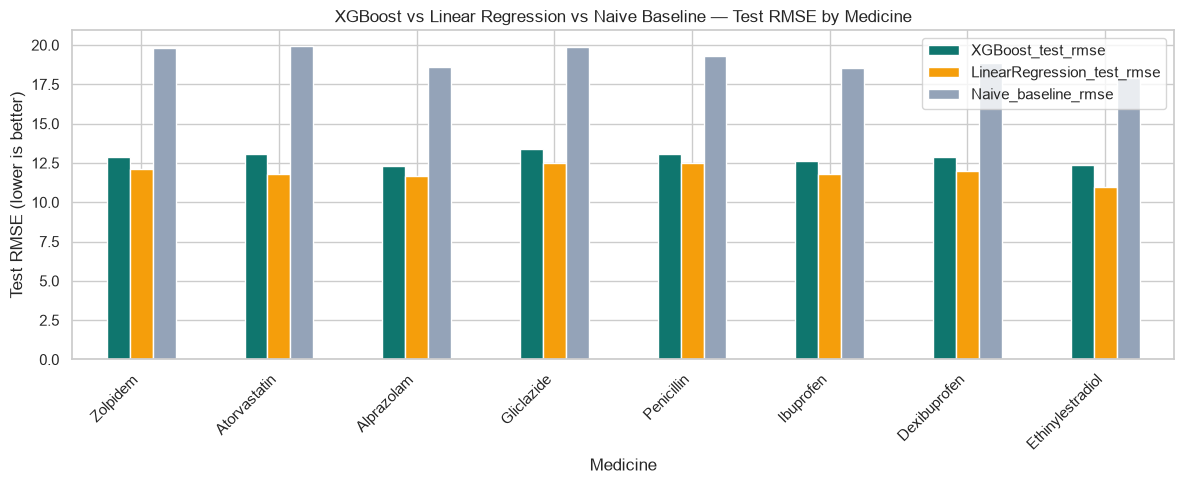

In [13]:
comparison_df.plot(kind="bar", figsize=(12, 5), color=["#0F766E", "#F59E0B", "#94A3B8"])
plt.ylabel("Test RMSE (lower is better)")
plt.title("XGBoost vs Linear Regression vs Naive Baseline — Test RMSE by Medicine")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. Feature importance

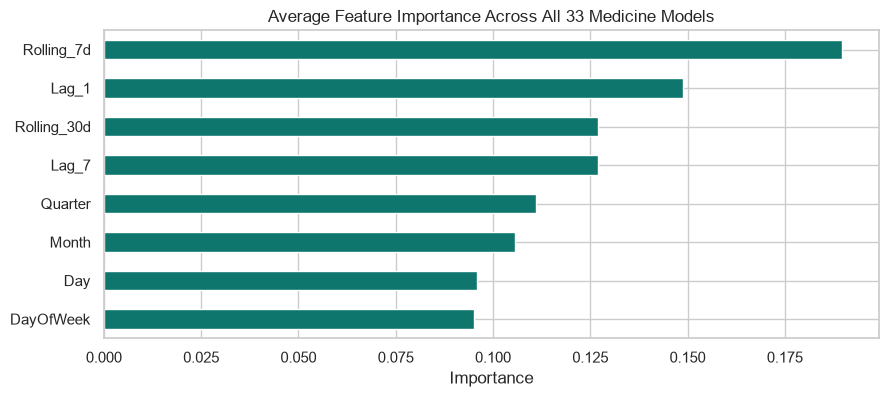

In [14]:
importance_df = pd.DataFrame({m: d["feature_importance"] for m, d in metrics.items()}).T
avg_importance = importance_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots()
avg_importance.plot(kind="barh", ax=ax, color=ACCENT)
ax.invert_yaxis()
ax.set_title("Average Feature Importance Across All 33 Medicine Models")
ax.set_xlabel("Importance")
plt.show()

## 12. Conclusions & Limitations

**What worked:**
- A proper chronological train/test split caught an overfitting problem
  (train R² ≈ 0.90 vs. test R² ≈ 0) that in-sample evaluation alone would
  have completely hidden.
- Despite low R², the model beats a naive "tomorrow = yesterday" baseline by
  ~27% on test RMSE, on average — genuinely useful for reorder-timing
  decisions even though it doesn't "explain" most of the day-to-day variance.
- `Rolling_7d` (7-day rolling average of recent sales) is consistently the
  most important feature — recent demand trend matters more than calendar
  position (day-of-week/month) for this dataset.

**What didn't:**
- `External_Factor` was checked and found uncorrelated with sales — a
  negative result worth documenting rather than silently dropping.
- Absolute R² stays low across the board, suggesting day-to-day demand at the
  per-medicine level is dominated by noise this feature set can't capture.

**Limitations & future improvements:**
- 33 independent models are trained on ~1,000 rows each. A single **pooled
  model** with medicine as a categorical feature would share statistical
  strength across medicines and likely generalize better with the same data.
- Real external signals (actual holiday calendars, promotions, seasonal
  illness trends) would likely help more than the synthetic `External_Factor`
  column did.
- Given the inherent noise, **prediction intervals** (e.g., quantile
  regression) would be more honest to a pharmacist than a single point
  estimate of days-to-stockout.